# Daten einlesen und vorbereiten

In [2]:
import pandas as pd
from pycparser.plyparser import Coord

#from Scripts.Live_Session_Week1_1 import df
#from rich.columns import Columns

path_processed_data = '../Data/Processed/'
time_series_holidays = pd.read_csv(path_processed_data + 'timeseries_holidays.csv')

# Spalte 1 "Unnamed: 0" entfernen. Ist vermutlich irgendwann aus Index hervorgegangen
time_series_holidays = time_series_holidays.drop(columns="Unnamed: 0")

# Format der Spalte Datum richten
time_series_holidays['date'] = pd.to_datetime(time_series_holidays['date'])

time_series_holidays.head()

,date,unit_sales,national_holiday,day_type,day_category
0,2013-01-02,582.0,no,weekday,weekday
1,2013-01-03,310.0,no,weekday,weekday
2,2013-01-04,338.0,no,weekday,weekday
3,2013-01-05,654.0,yes!,weekend,holiday (weekend)
4,2013-01-06,979.0,no,weekend,weekend


# Feature Engineering
## Neue Features ausdenken

In [3]:
time_series_added_features = time_series_holidays.copy()

print(time_series_added_features["national_holiday"].unique())
print()
print(time_series_added_features["day_type"].unique())
print()
print(time_series_added_features["day_category"].unique())

['no' 'yes!']

['weekday' 'weekend']

['weekday' 'holiday (weekend)' 'weekend' 'holiday (weekday)']


In [4]:
# Bestehende Säulen ändern
# (a) Statt day_type (weekend or weekday) hat man lieber Nullen und Einsen -> neue Säule "is_weekday" erstellen und "day_type" löschen
time_series_added_features['is_weekday'] = (time_series_added_features['day_type'] == 'weekday').astype(int)
time_series_added_features = time_series_added_features.drop(columns='day_type')

# (b) Ich weiß ob Wochenende ist oder nicht durch (a). Nun will ich wissen ob Holiday ist oder nicht. Ich brauche nicht beides zusammen in einer Säule -> werfe Säule "day_category" raus
time_series_added_features['is_holiday'] = time_series_added_features['day_category'].str.contains('holiday').astype(int)
time_series_added_features = time_series_added_features.drop(columns='day_category')

# (c) Säule "national_holiday" überflüssig, da alle holidays = national holidays
time_series_added_features = time_series_added_features.drop(columns='national_holiday')

time_series_added_features.head(4)

,date,unit_sales,is_weekday,is_holiday
0,2013-01-02,582.0,1,0
1,2013-01-03,310.0,1,0
2,2013-01-04,338.0,1,0
3,2013-01-05,654.0,0,1


In [5]:
# (1) Zeitbasierte Features
time_series_added_features['dayofweek']    = time_series_added_features['date'].dt.dayofweek
time_series_added_features['dayofmonth']   = time_series_added_features['date'].dt.day
time_series_added_features['dayofyear']    = time_series_added_features['date'].dt.dayofyear
time_series_added_features['weekofyear']   = time_series_added_features['date'].dt.isocalendar().week.astype(int)
time_series_added_features['month']        = time_series_added_features['date'].dt.month
time_series_added_features['quarter']      = time_series_added_features['date'].dt.quarter  # quarter teilt das Jahr in 4 Abschnitte
time_series_added_features['is_weekend']   = time_series_added_features['date'].dt.dayofweek >= 5

# (2) Lag Features
time_series_added_features['lag_7']  = time_series_added_features['unit_sales'].shift(7)
time_series_added_features['lag_14'] = time_series_added_features['unit_sales'].shift(14)
time_series_added_features['lag_21'] = time_series_added_features['unit_sales'].shift(21)
time_series_added_features['lag_28'] = time_series_added_features['unit_sales'].shift(28)

# (3) Rolling Features
# (3a) Rolling Mean
## Bsp: Rolling Mean 7 mit Shift 1 beantwortet die Frage: Wie viel wurde im Mittel in den letzten 7 Tagen bis inkl. gestern verkauft?
time_series_added_features['rolling_mean_7']  = time_series_added_features['unit_sales'].shift(1).rolling(7).mean()
time_series_added_features['rolling_mean_14'] = time_series_added_features['unit_sales'].shift(1).rolling(14).mean()
time_series_added_features['rolling_mean_21'] = time_series_added_features['unit_sales'].shift(1).rolling(21).mean()
time_series_added_features['rolling_mean_28'] = time_series_added_features['unit_sales'].shift(1).rolling(28).mean()

# (3b) Rolling Std
time_series_added_features['rolling_std_7']   = time_series_added_features['unit_sales'].shift(1).rolling(7).std()
time_series_added_features['rolling_std_14']  = time_series_added_features['unit_sales'].shift(1).rolling(14).std()
time_series_added_features['rolling_std_21']  = time_series_added_features['unit_sales'].shift(1).rolling(21).std()
time_series_added_features['rolling_std_28']  = time_series_added_features['unit_sales'].shift(1).rolling(28).std()

# (3c) Rolling Max
time_series_added_features['rolling_max_7']   = time_series_added_features['unit_sales'].shift(1).rolling(7).max()
time_series_added_features['rolling_max_14']  = time_series_added_features['unit_sales'].shift(1).rolling(14).max()
time_series_added_features['rolling_max_21']  = time_series_added_features['unit_sales'].shift(1).rolling(21).max()
time_series_added_features['rolling_max_28']  = time_series_added_features['unit_sales'].shift(1).rolling(28).max()

# (3d) Rolling Min
time_series_added_features['rolling_min_7']   = time_series_added_features['unit_sales'].shift(1).rolling(7).min()
time_series_added_features['rolling_min_14']  = time_series_added_features['unit_sales'].shift(1).rolling(14).min()
time_series_added_features['rolling_min_21']  = time_series_added_features['unit_sales'].shift(1).rolling(21).min()
time_series_added_features['rolling_min_28']  = time_series_added_features['unit_sales'].shift(1).rolling(28).min()

# NaNs entfernen
# time_series_added_features = time_series_added_features.dropna()

time_series_added_features.head(4)

,date,unit_sales,is_weekday,is_holiday,dayofweek,dayofmonth,dayofyear,weekofyear,month,quarter,...,rolling_std_21,rolling_std_28,rolling_max_7,rolling_max_14,rolling_max_21,rolling_max_28,rolling_min_7,rolling_min_14,rolling_min_21,rolling_min_28
0,2013-01-02,582.0,1,0,2,2,2,1,1,1,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2013-01-03,310.0,1,0,3,3,3,1,1,1,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,2013-01-04,338.0,1,0,4,4,4,1,1,1,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,2013-01-05,654.0,0,1,5,5,5,1,1,1,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


### Speichern der Tabelle mit allen Features

In [5]:
time_series_added_features.to_csv("../Data/Processed/time_series_added_features.csv", index=True)

## Colinearität?

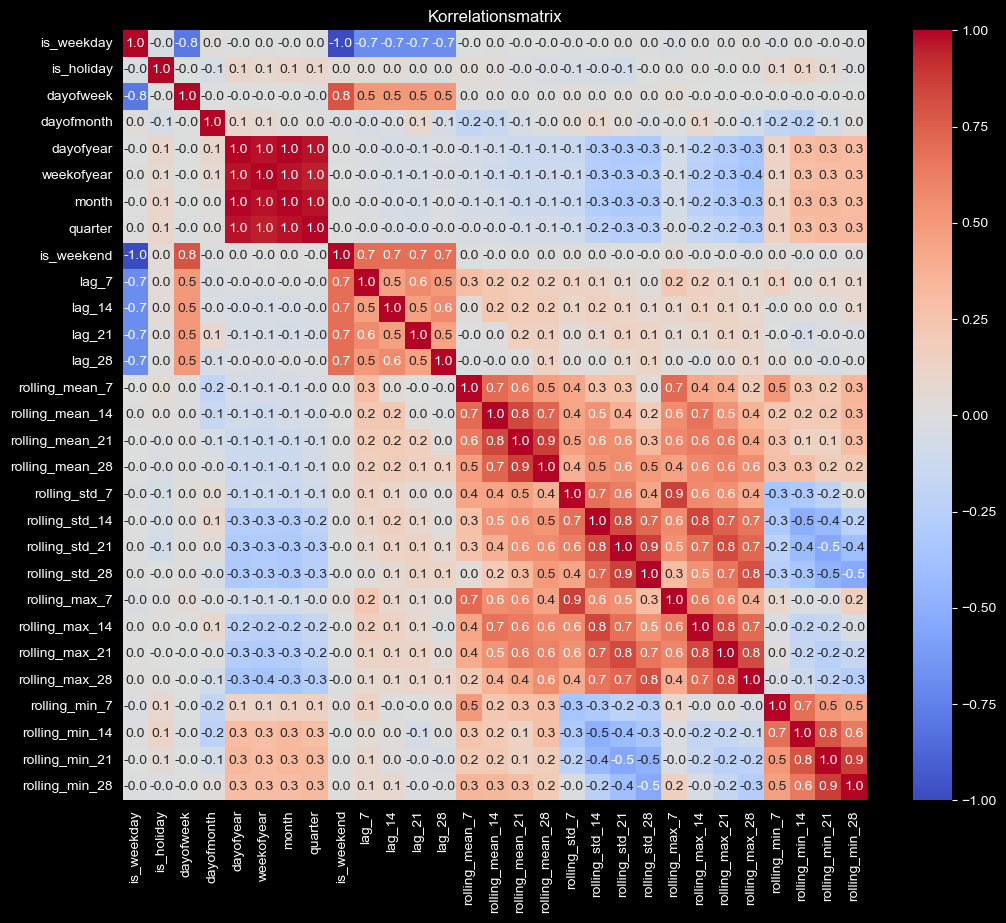

,is_weekday,is_holiday,dayofweek,dayofmonth,dayofyear,weekofyear,month,quarter,is_weekend,lag_7,...,rolling_std_21,rolling_std_28,rolling_max_7,rolling_max_14,rolling_max_21,rolling_max_28,rolling_min_7,rolling_min_14,rolling_min_21,rolling_min_28
is_weekday,1.000000,-0.046333,-0.790395,0.018385,-0.002062,0.003100,-0.003627,0.007413,-1.000000,-0.689565,...,0.001088,0.001427,-0.035160,0.006343,0.005860,0.008261,-0.026036,0.000681,-0.006348,-0.008510
is_holiday,-0.046333,1.000000,-0.005442,-0.050756,0.093275,0.064335,0.097600,0.091710,0.046333,0.032824,...,-0.080993,-0.004982,0.001860,0.011572,-0.000970,0.014606,0.084855,0.112958,0.053012,-0.022051
dayofweek,-0.790395,-0.005442,1.000000,-0.007093,-0.005881,-0.005824,-0.005298,-0.013616,0.790395,0.505530,...,0.009272,0.008516,0.040501,-0.003842,-0.002264,-0.004584,-0.001088,-0.009851,-0.002665,-0.000642
dayofmonth,0.018385,-0.050756,-0.007093,1.000000,0.088412,0.064172,0.008725,0.011107,-0.018385,-0.043515,...,0.025214,-0.044078,-0.000313,0.085046,-0.001078,-0.082930,-0.193883,-0.221639,-0.083431,0.021354
dayofyear,-0.002062,0.093275,-0.005881,0.088412,1.000000,0.975831,0.996792,0.970963,0.002062,-0.018548,...,-0.301661,-0.304974,-0.083683,-0.222820,-0.275591,-0.343968,0.131687,0.307520,0.326202,0.311991
weekofyear,0.003100,0.064335,-0.005824,0.064172,0.975831,1.000000,0.974511,0.952166,-0.003100,-0.024792,...,-0.291463,-0.286477,-0.066369,-0.240731,-0.290328,-0.356066,0.115910,0.289667,0.308491,0.305727
month,-0.003627,0.097600,-0.005298,0.008725,0.996792,0.974511,1.000000,0.973534,0.003627,-0.015207,...,-0.307395,-0.306354,-0.084955,-0.232053,-0.279007,-0.342338,0.147893,0.326411,0.334400,0.312448
quarter,0.007413,0.091710,-0.013616,0.011107,0.970963,0.952166,0.973534,1.000000,-0.007413,-0.014920,...,-0.250580,-0.257632,-0.042548,-0.160246,-0.204814,-0.267506,0.133290,0.293535,0.319759,0.318298
is_weekend,-1.000000,0.046333,0.790395,-0.018385,0.002062,-0.003100,0.003627,-0.007413,1.000000,0.689565,...,-0.001088,-0.001427,0.035160,-0.006343,-0.005860,-0.008261,0.026036,-0.000681,0.006348,0.008510
lag_7,-0.689565,0.032824,0.505530,-0.043515,-0.018548,-0.024792,-0.015207,-0.014920,0.689565,1.000000,...,0.065201,0.026106,0.221669,0.157764,0.115448,0.065390,0.142596,0.043352,0.081962,0.081684


In [6]:
import seaborn as sns
import matplotlib.pyplot as plt

X = time_series_added_features.drop(columns=['date', 'unit_sales'])
corr = X.corr()

plt.figure(figsize=(12, 10))
sns.heatmap(corr, annot=True, fmt=".1f", cmap="coolwarm")
plt.title("Korrelationsmatrix")
plt.show()

corr

In [7]:
# Hoch colineare features entfernen, da Problem für Linear Regression (XBoost hat dagegen KEIN Problem mit Colinearität!)

drop_cols = [
    "is_weekday",   # = Gegenteil von is_weekend
    "dayofyear",    # ≈ month (r=0.997)
    "quarter",      # ≈ month (r=0.974)
    "weekofyear",   # ≈ month (r=0.975)
    "rolling_max_7",
    "rolling_max_21",
    "rolling_max_28",
    "rolling_std_7",
    "rolling_std_21",
    "rolling_std_28",
    "rolling_min_7",
    "rolling_min_14",
    "rolling_min_28",
    "rolling_mean_7",
    "rolling_mean_14",
    "rolling_mean_28"
]

time_series_ALL_features = time_series_added_features.copy()
time_series_added_features_reduced_colinearity = time_series_added_features.drop(columns=drop_cols)

# Extreme Gradient Boosting (XGBoost)

## Splitten in Trainings- und Testdaten

In [17]:
# (1) Splitten => Chronologisch splitten. Nicht wie in "normalen" ML randomisiert in z.B. 20% Test und 80% Train Data splitten!!
# (1a) Sortieren (sicherheitshalber)
time_series_ALL_features = time_series_ALL_features.sort_values("date")

# (1b) Zielvariable und Features definieren
y = time_series_ALL_features['unit_sales']

# (1c) Features definieren
X = time_series_ALL_features.drop(columns=['unit_sales', 'date'])

# (1d) Zeitraum-basierter Split
train_filter = time_series_ALL_features["date"] < "2014-01-01"
test_filter  = (time_series_ALL_features["date"] >= "2014-01-01") & \
               (time_series_ALL_features["date"] <= "2014-03-31")        # => Das "\" sagt dem Interpreter: „Die nächste Zeile gehört noch zu diesem Ausdruck."

X_train = X[train_filter]
y_train = y[train_filter]

X_test = X[test_filter]
y_test = y[test_filter]

## Modell definieren und trainieren

In [18]:
from xgboost import XGBRegressor

model_xgb = XGBRegressor(
    n_estimators=200,    # Anzahl Bäume
    learning_rate=0.1,   # Lernrate
    max_depth=5,         # Tiefe der Bäume
    random_state=42
)

model_xgb.fit(X_train, y_train)

,"objective objective: typing.Union[str, xgboost.sklearn._SklObjWProto, typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]], NoneType]Specify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'reg:squarederror'
,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,None
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes

## Vorhersage

In [19]:
y_pred_xgb = model_xgb.predict(X_test)

## Evaluation

In [20]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

mae  = mean_absolute_error(y_test, y_pred_xgb)
mse  = mean_squared_error(y_test, y_pred_xgb)
rmse = np.sqrt(mse)
r2   = r2_score(y_test, y_pred_xgb)

print(f"XGBoost MAE:  {mae:.2f}")
print(f"XGBoost MSE:  {mse:.2f}")
print(f"XGBoost RMSE: {rmse:.2f}")
print(f"XGBoost R²:   {r2:.4f}")

XGBoost MAE:  98.69
XGBoost MSE:  22359.34
XGBoost RMSE: 149.53
XGBoost R²:   0.3358


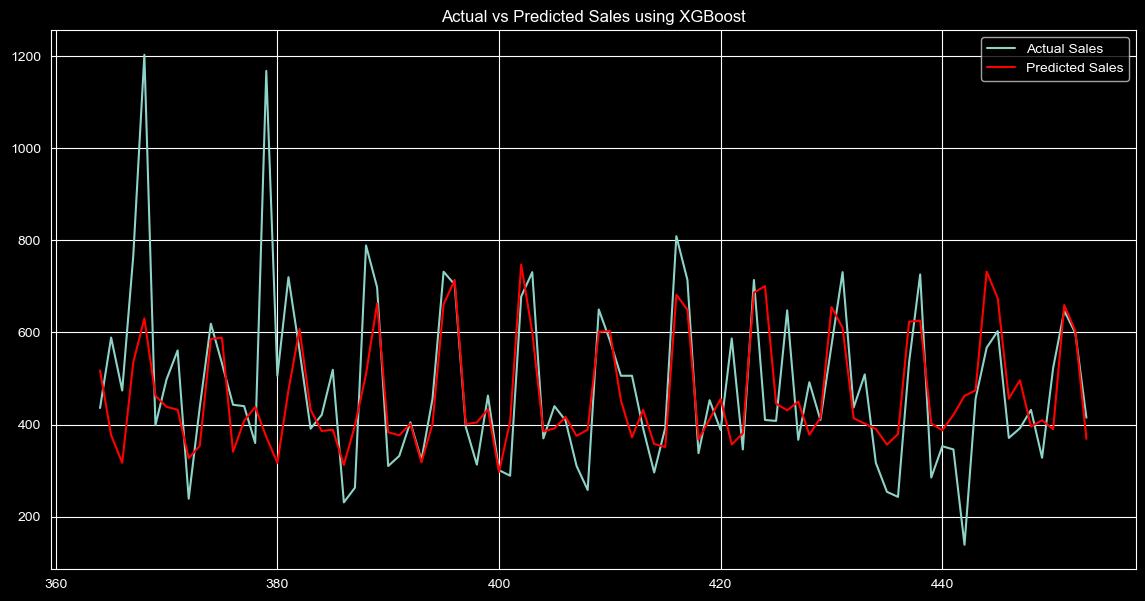

In [21]:
# Ist- vs. Prognosewerte plotten
plt.figure(figsize=(14, 7))
plt.plot(y_test.index, y_test.values, label='Actual Sales')
plt.plot(y_test.index, y_pred_xgb, label='Predicted Sales', color='red')
plt.title('Actual vs Predicted Sales using XGBoost')
plt.legend()
plt.show()

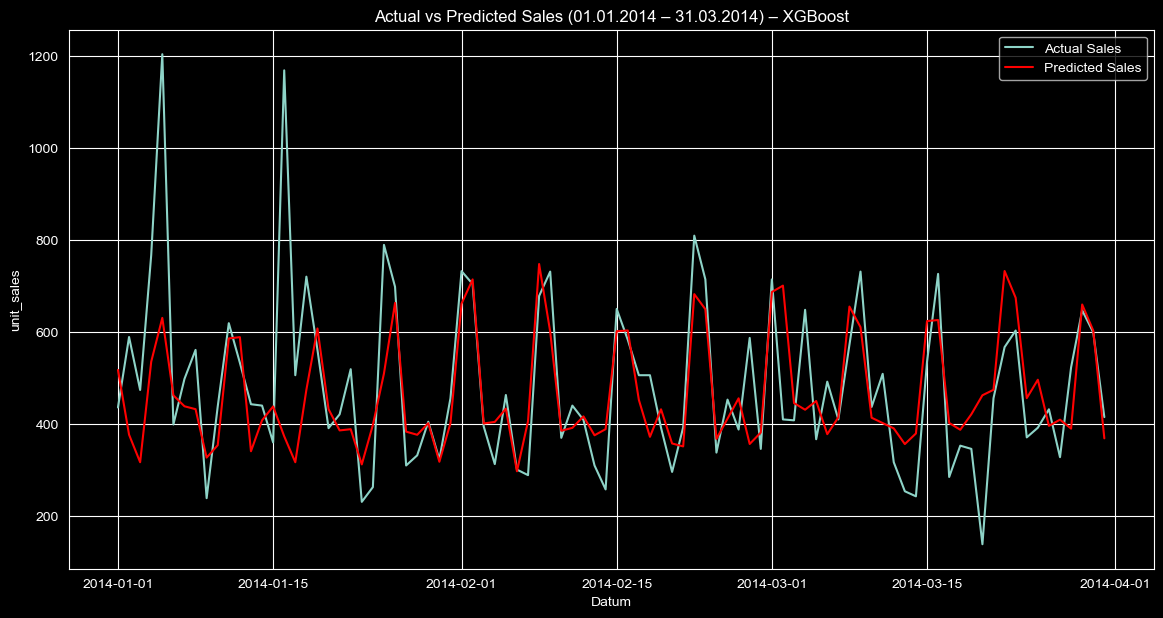

In [22]:
test_filter = (
    (time_series_ALL_features["date"] >= "2014-01-01") &
    (time_series_ALL_features["date"] <= "2014-03-31")
)

test_dates = time_series_ALL_features.loc[test_filter, "date"]

# Datum aus dem Original-DataFrame holen
test_dates = time_series_ALL_features.loc[test_filter, "date"]

plt.figure(figsize=(14, 7))
plt.plot(test_dates, y_test.values, label='Actual Sales')
plt.plot(test_dates, y_pred_xgb, label='Predicted Sales', color='red')
plt.title('Actual vs Predicted Sales (01.01.2014 – 31.03.2014) – XGBoost')
plt.xlabel("Datum")
plt.ylabel("unit_sales")
plt.legend()
plt.show()

## Hyperopt (Hyperparameter Optimization)
### Define the hyperparameter search space

In [23]:
from hyperopt import fmin, tpe, hp, Trials, STATUS_OK
import numpy as np

space = {
    # Baumstruktur
    'n_estimators':   hp.quniform('n_estimators', 50, 500, 10),
    'max_depth':      hp.quniform('max_depth', 3, 10, 1),

    # Lernrate
    'learning_rate':  hp.loguniform('learning_rate', np.log(0.01), np.log(0.3)),

    # Regularisierung
    'reg_alpha':      hp.loguniform('reg_alpha', np.log(0.001), np.log(10)),
    'reg_lambda':     hp.loguniform('reg_lambda', np.log(0.001), np.log(10)),

    # Subsampling
    'subsample':      hp.uniform('subsample', 0.5, 1.0),
    'colsample_bytree': hp.uniform('colsample_bytree', 0.5, 1.0),

    # Overfitting
    'min_child_weight': hp.quniform('min_child_weight', 1, 10, 1),
    'gamma':          hp.loguniform('gamma', np.log(0.001), np.log(10)),
}

| Parameter | Bedeutung |
|-----------|-----------|
| `n_estimators` | Anzahl Bäume |
| `max_depth` | Maximale Baumtiefe – hoch = overfitting |
| `learning_rate` | Schrittgröße – klein = langsamer aber stabiler |
| `reg_alpha/lambda` | L1/L2 Regularisierung |
| `subsample` | Anteil der Daten pro Baum |
| `colsample_bytree` | Anteil der Features pro Baum |
| `min_child_weight` | Mindestgewicht pro Blatt – verhindert overfitting |
| `gamma` | Mindestgewinn für Split – konservativere Bäume |

### Define Objective Function

### Define Objective Function
#### Ohne Cross Validation

In [15]:
"""
=> ALTE Objective Function OHNE Cross-Validation (was nochmal einiges an "Kompliziertheit" mit reinbringt)


def objective(params):
    params = {
        'n_estimators':     int(params['n_estimators']),
        'max_depth':        int(params['max_depth']),
        'learning_rate':    params['learning_rate'],
        'reg_alpha':        params['reg_alpha'],
        'reg_lambda':       params['reg_lambda'],
        'subsample':        params['subsample'],
        'colsample_bytree': params['colsample_bytree'],
        'min_child_weight': int(params['min_child_weight']),
        'gamma':            params['gamma'],
    }

    model = XGBRegressor(
        **params,
        random_state=42,
        n_jobs=-1
    )

    model.fit(X_train, y_train)
    predicted = model.predict(X_test)
    errors = y_test - predicted

    smape = np.mean(2 * np.abs(errors) / (np.abs(y_test) + np.abs(predicted)))
    rmse  = np.sqrt(mean_squared_error(y_test, predicted))
    mad   = np.mean(np.abs(errors))
    rmad  = mad / np.mean(y_test)
    mape  = np.mean(np.abs(errors) / np.abs(y_test)) * 100
    bias  = np.mean(errors)

    return {
        'loss':   smape,
        'status': STATUS_OK,
        'rmse':   rmse,
        'mad':    mad,
        'rmad':   rmad,
        'mape':   mape,
        'bias':   bias,
    }
"""

'\n=> ALTE Objective Function OHNE Cross-Validation (was nochmal einiges an "Kompliziertheit" mit reinbringt)\n\n\ndef objective(params):\n    params = {\n        \'n_estimators\':     int(params[\'n_estimators\']),\n        \'max_depth\':        int(params[\'max_depth\']),\n        \'learning_rate\':    params[\'learning_rate\'],\n        \'reg_alpha\':        params[\'reg_alpha\'],\n        \'reg_lambda\':       params[\'reg_lambda\'],\n        \'subsample\':        params[\'subsample\'],\n        \'colsample_bytree\': params[\'colsample_bytree\'],\n        \'min_child_weight\': int(params[\'min_child_weight\']),\n        \'gamma\':            params[\'gamma\'],\n    }\n\n    model = XGBRegressor(\n        **params,\n        random_state=42,\n        n_jobs=-1\n    )\n\n    model.fit(X_train, y_train)\n    predicted = model.predict(X_test)\n    errors = y_test - predicted\n\n    smape = np.mean(2 * np.abs(errors) / (np.abs(y_test) + np.abs(predicted)))\n    rmse  = np.sqrt(mean_squar

#### Mit Crossvalidation

In [24]:
from sklearn.model_selection import TimeSeriesSplit, cross_val_score
from sklearn.metrics import make_scorer

# Custom SMAPE Scorer da sklearn SMAPE nicht nativ unterstützt (siehe Erklärung vorherige Box)
def smape_score(y_true, y_pred):
    return np.mean(2 * np.abs(y_true - y_pred) / (np.abs(y_true) + np.abs(y_pred)))

# greater_is_better=False da SMAPE ein Fehlermaß ist (kleiner = besser)
# sklearn negiert den Score intern => daher später -scores.mean()
smape_scorer = make_scorer(smape_score, greater_is_better=False)

# Zeitreihen-CV: respektiert zeitliche Reihenfolge, kein Data Leakage
tscv = TimeSeriesSplit(n_splits=5)

def objective(params):

    # quniform gibt floats zurück => int() cast nötig
    params = {
        'n_estimators':     int(params['n_estimators']),
        'max_depth':        int(params['max_depth']),
        'learning_rate':    params['learning_rate'],
        'reg_alpha':        params['reg_alpha'],
        'reg_lambda':       params['reg_lambda'],
        'subsample':        params['subsample'],
        'colsample_bytree': params['colsample_bytree'],
        'min_child_weight': int(params['min_child_weight']),
        'gamma':            params['gamma'],
    }

    model = XGBRegressor(**params, random_state=42, n_jobs=-1)

    # SMAPE über 5 CV-Folds berechnen => robuster gegen Overfitting
    scores = cross_val_score(model, X_train, y_train, cv=tscv, scoring=smape_scorer)
    smape_cv = -scores.mean()  # negieren da greater_is_better=False

    # Finales Fit auf gesamtem Trainingsset für Testset-Metriken
    model.fit(X_train, y_train)
    predicted = model.predict(X_test)
    errors = y_test - predicted

    # Weitere Metriken nur zum Loggen, nicht zur Optimierung
    rmse = np.sqrt(mean_squared_error(y_test, predicted))
    mad  = np.mean(np.abs(errors))
    rmad = mad / np.mean(y_test)
    mape = np.mean(np.abs(errors) / np.abs(y_test)) * 100
    bias = np.mean(errors)

    return {
        'loss':   smape_cv,  # Hyperopt minimiert diesen Wert
        'status': STATUS_OK,
        'rmse':   rmse,
        'mad':    mad,
        'rmad':   rmad,
        'mape':   mape,
        'bias':   bias,
    }

### Run Optimization

In [25]:
from hyperopt import fmin, tpe, hp, Trials, STATUS_OK

# Initialize trials object to track progress
trials_XGB = Trials()

# Run optimization
best_XGB = fmin(
    fn=objective,
    space=space,
    algo=tpe.suggest,
    max_evals=200,
    trials=trials_XGB
)

print("\nBest parameters found:")
print(best_XGB)

# Alle Metriken als DataFrame
results_XGB = pd.DataFrame(trials_XGB.results)

100%|██████████| 200/200 [07:43<00:00,  2.32s/trial, best loss: 0.182329100582918]  

Best parameters found:
{'colsample_bytree': np.float64(0.5676483463195157), 'gamma': np.float64(0.0015242971816619745), 'learning_rate': np.float64(0.017063745230877073), 'max_depth': np.float64(5.0), 'min_child_weight': np.float64(10.0), 'n_estimators': np.float64(150.0), 'reg_alpha': np.float64(0.3767340284307578), 'reg_lambda': np.float64(0.5167880556034004), 'subsample': np.float64(0.5940571984220062)}


In [18]:
results_XGB.rename(columns={'loss': 'smape_cv'}).sort_values('smape_cv').head(1)

,smape_cv,status,rmse,mad,rmad,mape,bias
145,0.181647,ok,142.552747,95.068186,0.195905,21.401739,19.657384


## Finales Modell mit besten Hyperparametern
### Beste Hyperparameter extrahieren

In [19]:
import pandas as pd

# Besten Trial finden
best_trial = trials_XGB.best_trial['misc']['vals']

# Parameter extrahieren und int() cast
best_params_XGB = {
    'n_estimators':     int(best_trial['n_estimators'][0]),
    'max_depth':        int(best_trial['max_depth'][0]),
    'learning_rate':    best_trial['learning_rate'][0],
    'reg_alpha':        best_trial['reg_alpha'][0],
    'reg_lambda':       best_trial['reg_lambda'][0],
    'subsample':        best_trial['subsample'][0],
    'colsample_bytree': best_trial['colsample_bytree'][0],
    'min_child_weight': int(best_trial['min_child_weight'][0]),
    'gamma':            best_trial['gamma'][0],
}

print(best_params_XGB)

{'n_estimators': 170, 'max_depth': 3, 'learning_rate': np.float64(0.013953292201506299), 'reg_alpha': np.float64(0.9051691206948077), 'reg_lambda': np.float64(0.9440140157131163), 'subsample': np.float64(0.5340136256394008), 'colsample_bytree': np.float64(0.730798325280967), 'min_child_weight': 8, 'gamma': np.float64(3.4914561007517886)}


### Trainieren

In [20]:
# int() cast nötig da quniform floats zurückgibt
best_params_XGB['n_estimators']     = int(best_params_XGB['n_estimators'])
best_params_XGB['max_depth']        = int(best_params_XGB['max_depth'])
best_params_XGB['min_child_weight'] = int(best_params_XGB['min_child_weight'])

# Finales Modell mit besten Parametern
final_model_XGB = XGBRegressor(**best_params_XGB, random_state=42, n_jobs=-1)
final_model_XGB.fit(X_train, y_train)

,"objective objective: typing.Union[str, xgboost.sklearn._SklObjWProto, typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]], NoneType]Specify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'reg:squarederror'
,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,np.float64(0.730798325280967)
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.data

### Forecast (One-Step Forecast)

In [21]:
# (1) Vorhersagen erstellen (One-Step-ahead Approach, nicht iteratives Forecasting der Einfachheitshalber!!)
y_pred = final_model_XGB.predict(X_test)

### Evaluation (One-Step Forecast)

In [22]:
# (2) Evaluation
# (2a) Definition der Forecast Metric
def forecast_metrics(y_true, y_pred):
    errors = y_true - y_pred
    smape = np.mean(2 * np.abs(errors) / (np.abs(y_true) + np.abs(y_pred)))
    rmse  = np.sqrt(mean_squared_error(y_true, y_pred))
    mad   = np.mean(np.abs(errors))
    rmad  = mad / np.mean(y_true)
    mape  = np.mean(np.abs(errors) / np.abs(y_true)) * 100
    bias  = np.mean(errors)

    return {
        'SMAPE': smape,
        'RMSE':  rmse,
        'MAD':   mad,
        'rMAD':  rmad,
        'MAPE':  mape,
        'Bias':  bias,
    }
# (2b) Metriken berechnen
metrics = forecast_metrics(y_test, y_pred)
for k, v in metrics.items():
    print(f"{k}: {v:,.2f}")

SMAPE: 0.20
RMSE: 142.55
MAD: 95.07
rMAD: 0.20
MAPE: 21.40
Bias: 19.66


### Plotting (One-Step Forecast)

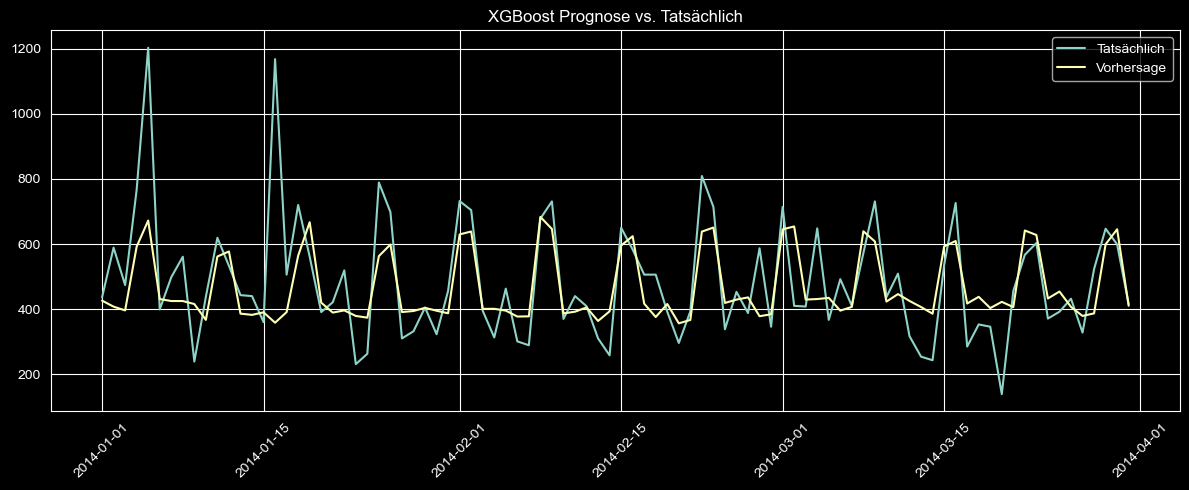

In [24]:
test_dates = time_series_ALL_features[
    (time_series_ALL_features['date'] >= '2014-01-01') &
    (time_series_ALL_features['date'] <= '2014-03-31')
]['date'].values

fig, ax = plt.subplots(figsize=(12, 5))  # fig = Figure-Objekt (für mlflow.log_figure), ax = Achsen-Objekt (zum Plotten)
plt.plot(test_dates, y_test.values, label='Tatsächlich')
plt.plot(test_dates, y_pred, label='Vorhersage')
plt.legend()
plt.title('XGBoost Prognose vs. Tatsächlich')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

### Feature Importance

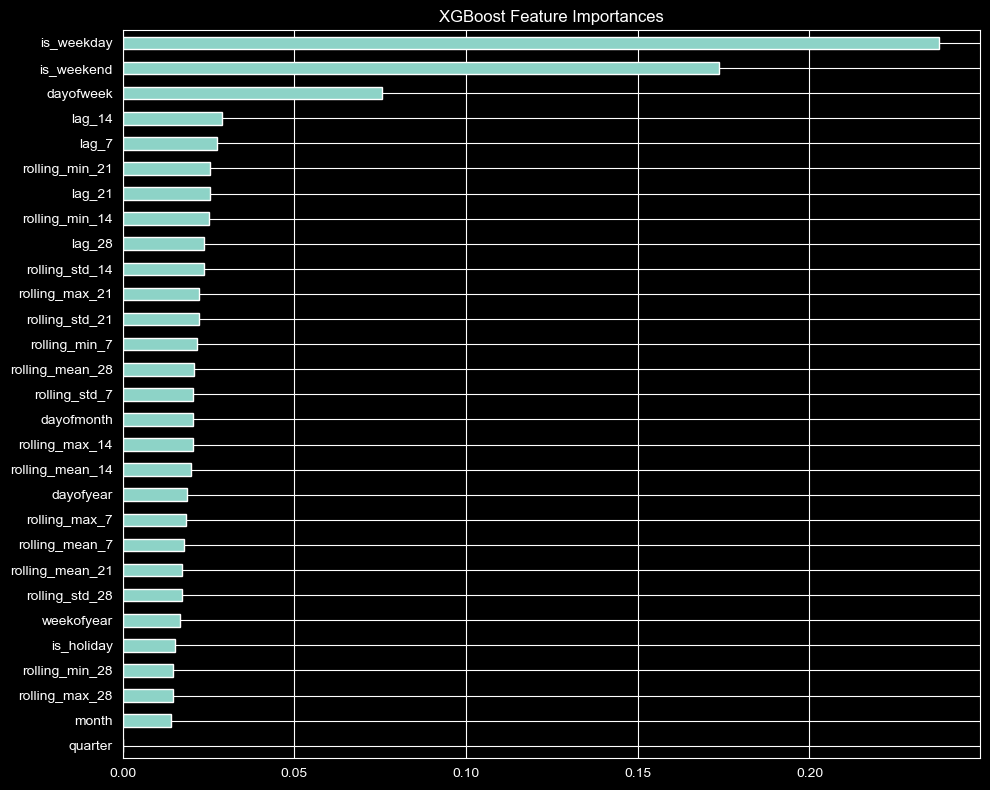

In [25]:
import pandas as pd
import matplotlib.pyplot as plt

# Feature Importance Plot mit fig-Objekt erstellen (nötig für mlflow.log_figure)
importances = pd.Series(
    final_model_XGB.feature_importances_,
    index=final_model_XGB.get_booster().feature_names
)

fig_XGB_importance, ax = plt.subplots(figsize=(10, 8))
importances.sort_values().plot(kind='barh', figsize=(10, 8))
plt.title('XGBoost Feature Importances')
plt.tight_layout()
plt.show()

## ML flow
### Starten

In [26]:
import mlflow
import mlflow.xgboost

mlflow.set_tracking_uri("sqlite:////Users/matthiasmuschket/PycharmProjects/260414_Time_Series_Masterschool/mlflow.db")
mlflow.set_experiment("sales_forecast")

/opt/miniconda3/envs/work/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


<Experiment: artifact_location='/Users/matthiasmuschket/PycharmProjects/260414_Time_Series_Masterschool/Scripts/mlruns/1', creation_time=1777470068881, experiment_id='1', last_update_time=1777470068881, lifecycle_stage='active', name='sales_forecast', tags={}, trace_location=None, workspace='default'>

In [27]:
# Jetzt wichtig: mlflow ui mit der DB starten. Im Terminal:
# mlflow ui --backend-store-uri sqlite:////Users/matthiasmuschket/PycharmProjects/260414_Time_Series_Masterschool/mlflow.db

### Logging

In [28]:
with mlflow.start_run(run_name="XGBoost"):

    # Qualitative Zusatzinfos zum Run (kein Hyperparameter, keine Metrik, aber z.B. "welche Methode", "welches Dataset")
    mlflow.set_tag("forecasting_method", "one-step-ahead")
    mlflow.set_tag("model_type", "ML")

    # Beste Hyperparameter loggen
    mlflow.log_params(best_params_XGB)

    # Train/Test-Split Info loggen
    mlflow.log_param("train_size", len(X_train))
    mlflow.log_param("test_size", len(X_test))
    mlflow.log_param("test_start", "2014-01-01")
    mlflow.log_param("test_end", "2014-03-31")

    # Genutzte Features loggen
    mlflow.log_param("features", list(X_train.columns))

    # Evaluationsmetriken loggen (bereits berechnet)
    mlflow.log_metric("SMAPE", metrics["SMAPE"])
    mlflow.log_metric("RMSE",  metrics["RMSE"])
    mlflow.log_metric("MAD",   metrics["MAD"])
    mlflow.log_metric("rMAD",  metrics["rMAD"])
    mlflow.log_metric("MAPE",  metrics["MAPE"])
    mlflow.log_metric("Bias",  metrics["Bias"])

    # Forecast-Plot als Artefakt speichern
    mlflow.log_figure(fig, "forecast_plot.png")

    # Feature Importance Plot als Artefakt speichern
    mlflow.log_figure(fig_XGB_importance, "feature_importance.png")

    # Trainiertes Modell als Artefakt speichern
    ## also:
    ## alle Entscheidungsbäume (bei XGBoost sind das typischerweise hunderte)
    ## für jeden Baum: welche Feature-Splits, welche Schwellenwerte, welche Blatt-Werte
    ## alle Hyperparameter
    ## Später kannst man in Streamlit einfach: "model = mlflow.xgboost.load_model("runs://<run_id>/model")" und hast das komplette trainierte Modell zurück – ohne nochmal trainieren zu müssen!
    mlflow.xgboost.log_model(final_model_XGB, name="model")

# Linear Regression
## Theorie kurz

- "Logistic Regression": für Klassifikation, wie bekannt
- "LINEAR Regression": gleiches Prinzip für Regression wird historisch bedingt nicht Logistic sondern Linear Regression genannt
- da hier viele Features vorhanden sind, wäre der exakte Titel eigentlich "MULTIPLE linear regression". Allerdings hat sich schlicht "Linear Regression" im Sprachgebrauch durchgesetzt

## Daten vorbereiten

In [29]:
# (1) NaNs entfernen (damit kann linear Regression nicht umgehen)
time_series_added_features_reduced_colinearity_NAsDropped = time_series_added_features_reduced_colinearity.dropna()

# (2) Splitten => Chronologisch splitten. Nicht wie in "normalen" ML randomisiert in z.B. 20% Test und 80% Train Data splitten!!
# (2a) Sortieren (sicherheitshalber)
time_series_added_features_reduced_colinearity_NAsDropped = time_series_added_features_reduced_colinearity_NAsDropped.sort_values("date")

# (2b) Zielvariable und Features definieren
y = time_series_added_features_reduced_colinearity_NAsDropped['unit_sales']

# (2c) Features definieren
X = time_series_added_features_reduced_colinearity_NAsDropped.drop(columns=['unit_sales', 'date'])

# (2d) Zeitraum-basierter Split
train_filter = time_series_added_features_reduced_colinearity_NAsDropped["date"] < "2014-01-01"
test_filter  = (time_series_added_features_reduced_colinearity_NAsDropped["date"] >= "2014-01-01") & \
               (time_series_added_features_reduced_colinearity_NAsDropped["date"] <= "2014-03-31")        # => Das "\" sagt dem Interpreter: „Die nächste Zeile gehört noch zu diesem Ausdruck."

X_train = X[train_filter]
y_train = y[train_filter]

X_test = X[test_filter]
y_test = y[test_filter]


## Model definition, training and predictions

In [30]:
from sklearn.linear_model import LinearRegression

model_lr = LinearRegression()
model_lr.fit(X_train, y_train)
y_pred_lr = model_lr.predict(X_test)

## Evaluation

In [31]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

mae  = mean_absolute_error(y_test, y_pred_lr)
mse  = mean_squared_error(y_test, y_pred_lr)
rmse = np.sqrt(mse)
r2   = r2_score(y_test, y_pred_lr)

print(f"Linear Regression MAE:  {mae:.2f}")
print(f"Linear Regression MSE:  {mse:.2f}")
print(f"Linear Regression RMSE: {rmse:.2f}")
print(f"Linear Regression R²:   {r2:.4f}")

Linear Regression MAE:  92.72
Linear Regression MSE:  18813.96
Linear Regression RMSE: 137.16
Linear Regression R²:   0.4411


In [32]:
# Wird später in ML-Flow importiert!
metrics_LR = forecast_metrics(y_test, y_pred_lr)

## Feature Importance

In [33]:
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.pipeline import Pipeline

pipeline_lr = Pipeline([
    ("scaler", StandardScaler()),
    ("model",  LinearRegression())
])

pipeline_lr.fit(X_train, y_train)
y_pred_lr = pipeline_lr.predict(X_test)

# Koeffizienten nach Skalierung (Koeffizienten (nach Standardisierung) sind das Maß für Feature Importance bei Linear Regression)
import pandas as pd
coefs = pipeline_lr.named_steps["model"].coef_
importance_lr = pd.DataFrame({
    "Feature":     X_train.columns,
    "Coefficient": coefs
}).sort_values("Coefficient", key=abs, ascending=False)

print(importance_lr)

            Feature  Coefficient
4        is_weekend    78.351970
6            lag_14    19.910941
11   rolling_max_14    15.412712
7            lag_21    14.557416
8            lag_28    14.351827
2        dayofmonth   -13.901131
9   rolling_mean_21   -12.712469
12   rolling_min_21    10.781252
10   rolling_std_14    -9.159850
0        is_holiday     8.875619
5             lag_7     8.088798
1         dayofweek    -6.639833
3             month     2.743091


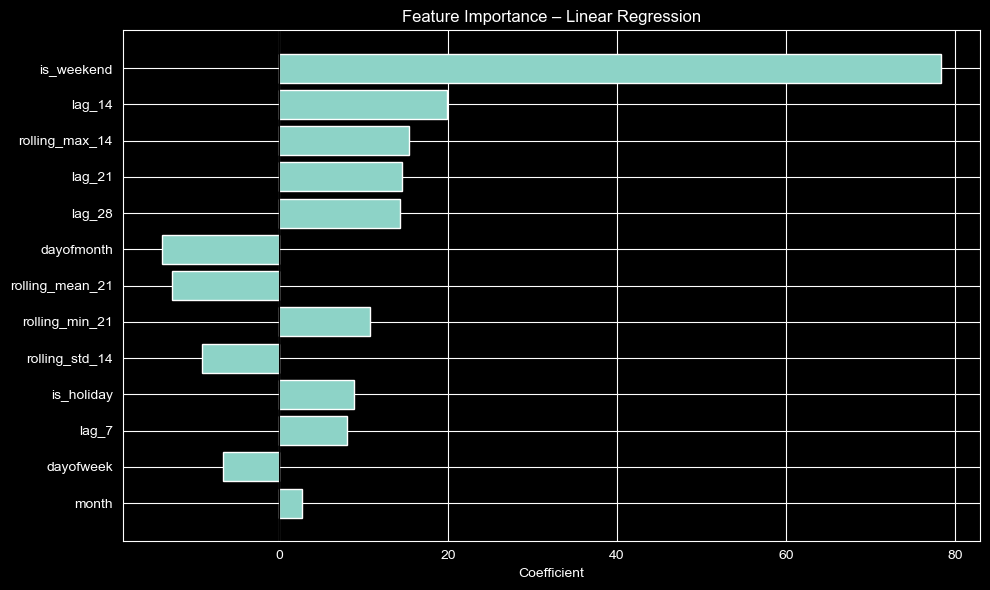

In [34]:
import matplotlib.pyplot as plt

# Sortieren nach Absolutwert (größter Einfluss oben)
importance_sorted = importance_lr.sort_values("Coefficient", key=abs, ascending=True)

fig_LR_importance, ax = plt.subplots(figsize=(10, 6))
plt.barh(importance_sorted["Feature"], importance_sorted["Coefficient"])
plt.axvline(x=0, color="black", linewidth=0.8)  # Nulllinie
plt.xlabel("Coefficient")
plt.title("Feature Importance – Linear Regression")
plt.tight_layout()
plt.show()

## Hyperopt (Hyperparameter Optimization)

LinearRegression hat keine Hyperparameter!!! => Optimierung nicht nötig/möglich

## Plotten

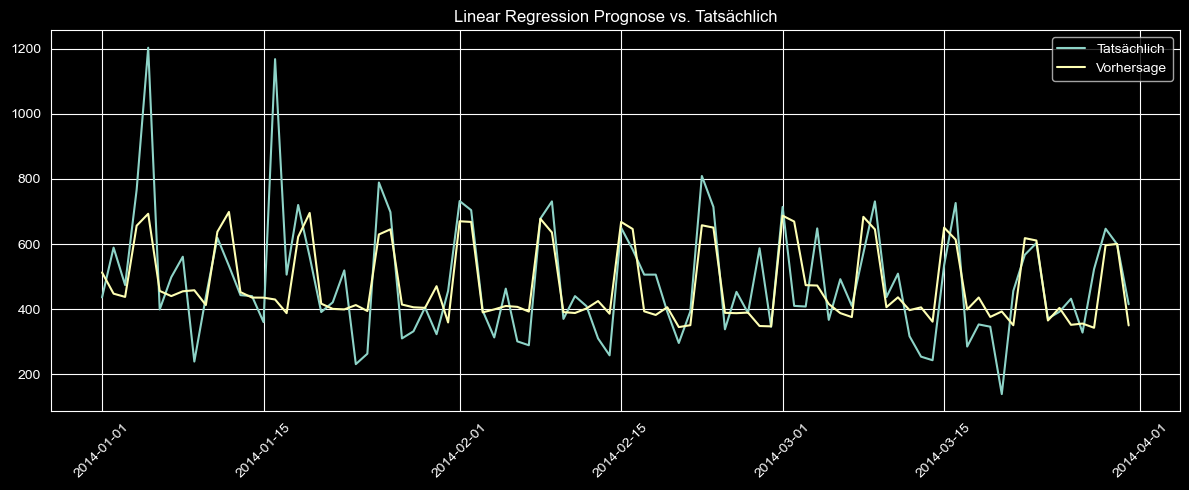

In [35]:
# Plot erstellen (fig-Objekt nötig für mlflow.log_figure)
fig_LR, ax = plt.subplots(figsize=(12, 5))
test_dates_LR = time_series_added_features_reduced_colinearity_NAsDropped.loc[y_test.index, 'date']
ax.plot(test_dates_LR, y_test.values, label='Tatsächlich')
ax.plot(test_dates_LR, y_pred_lr, label='Vorhersage')
ax.legend()
ax.set_title('Linear Regression Prognose vs. Tatsächlich')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

## ML Flow Logging

In [36]:
with mlflow.start_run(run_name="Linear_Regression"):

    # Qualitative Zusatzinfos
    mlflow.set_tag("forecasting_method", "one-step-ahead")
    mlflow.set_tag("model_type", "ML")

    # Keine Hyperparameter (Linear Regression hat keine)

    # Train/Test-Split Info loggen
    mlflow.log_param("train_size", len(X_train))
    mlflow.log_param("test_size", len(X_test))
    mlflow.log_param("test_start", "2014-01-01")
    mlflow.log_param("test_end", "2014-03-31")

    # Genutzte Features loggen
    mlflow.log_param("features", list(X_train.columns))

    # Evaluationsmetriken loggen
    mlflow.log_metric("SMAPE", metrics_LR["SMAPE"])
    mlflow.log_metric("RMSE",  metrics_LR["RMSE"])
    mlflow.log_metric("MAD",   metrics_LR["MAD"])
    mlflow.log_metric("rMAD",  metrics_LR["rMAD"])
    mlflow.log_metric("MAPE",  metrics_LR["MAPE"])
    mlflow.log_metric("Bias",  metrics_LR["Bias"])

    # Forecast-Plot als Artefakt speichern
    mlflow.log_figure(fig_LR, "forecast_plot.png")

    # Feature Importance Plot als Artefakt speichern
    mlflow.log_figure(fig_LR_importance, "feature_importance.png")

    # Trainiertes Modell speichern
    mlflow.sklearn.log_model(pipeline_lr, name="model")

2026/04/30 13:59:22 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


# Random Forest
## Daten vorbereiten

In [26]:
# (1) NaNs entfernen (damit kann Random Forest nicht umgehen); Allerdings kann Random Forest genau wie XGBoost mit Colinearity umgehen!
time_series_ALL_features_NAsDropped = time_series_ALL_features.dropna()

# (2) Splitten => Chronologisch splitten. Nicht wie in "normalen" ML randomisiert in z.B. 20% Test und 80% Train Data splitten!!
# (2a) Sortieren (sicherheitshalber)
time_series_ALL_features_NAsDropped = time_series_ALL_features_NAsDropped.sort_values("date")

# (2b) Zielvariable und Features definieren
y = time_series_ALL_features_NAsDropped['unit_sales']

# (2c) Features definieren
X = time_series_ALL_features_NAsDropped.drop(columns=['unit_sales', 'date'])

# (2d) Zeitraum-basierter Split
train_filter = time_series_ALL_features_NAsDropped["date"] < "2014-01-01"
test_filter  = (time_series_ALL_features_NAsDropped["date"] >= "2014-01-01") & \
               (time_series_ALL_features_NAsDropped["date"] <= "2014-03-31")        # => Das "\" sagt dem Interpreter: „Die nächste Zeile gehört noch zu diesem Ausdruck."

X_train = X[train_filter]
y_train = y[train_filter]

X_test = X[test_filter]
y_test = y[test_filter]

## Model definition, training and predictions

In [30]:
from sklearn.ensemble import RandomForestRegressor

model_rf = RandomForestRegressor(
    n_estimators=1000,   # Anzahl Bäume
    max_depth=5,        # Tiefe der Bäume
    random_state=42
)

model_rf.fit(X_train, y_train)
y_pred_rf = model_rf.predict(X_test)

## Evaluation

In [39]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

mae = mean_absolute_error(y_test, y_pred_rf)
mse = mean_squared_error(y_test, y_pred_rf)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred_rf)

print(f"MAE:  {mae:.2f}")
print(f"MSE:  {mse:.2f}")
print(f"RMSE: {rmse:.2f}")
print(f"R²:   {r2:.4f}")

MAE:  93.25
MSE:  20157.81
RMSE: 141.98
R²:   0.4012


## Feature Importance

In [40]:
importance_rf = pd.DataFrame({
    "Feature":    X_train.columns,
    "Importance": model_rf.feature_importances_
}).sort_values("Importance", ascending=False)

print(importance_rf)

            Feature  Importance
2         dayofweek    0.224458
8        is_weekend    0.224172
0        is_weekday    0.211619
10           lag_14    0.040658
3        dayofmonth    0.032967
12           lag_28    0.029691
11           lag_21    0.026418
25    rolling_min_7    0.021963
17    rolling_std_7    0.017936
9             lag_7    0.016081
14  rolling_mean_14    0.013140
20   rolling_std_28    0.012353
19   rolling_std_21    0.012173
4         dayofyear    0.012121
18   rolling_std_14    0.011331
16  rolling_mean_28    0.010537
15  rolling_mean_21    0.010176
13   rolling_mean_7    0.009790
28   rolling_min_28    0.009027
26   rolling_min_14    0.008806
22   rolling_max_14    0.007579
5        weekofyear    0.006859
24   rolling_max_28    0.006591
27   rolling_min_21    0.006063
21    rolling_max_7    0.005527
6             month    0.004916
23   rolling_max_21    0.003621
1        is_holiday    0.002586
7           quarter    0.000840


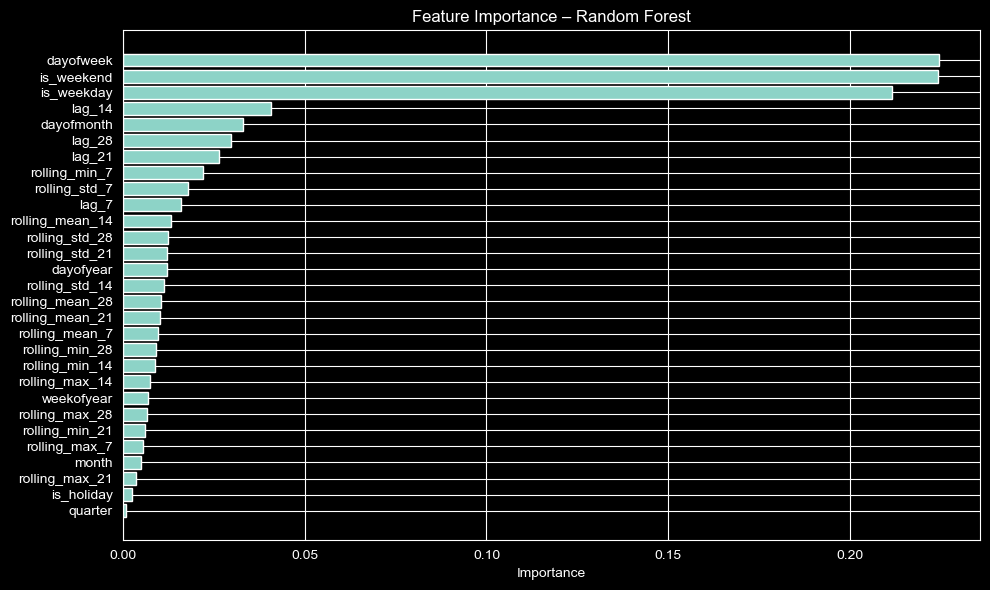

In [41]:
importance_sorted = importance_rf.sort_values("Importance", ascending=True)

plt.figure(figsize=(10, 6))
plt.barh(importance_sorted["Feature"], importance_sorted["Importance"])
plt.xlabel("Importance")
plt.title("Feature Importance – Random Forest")
plt.tight_layout()
plt.show()

## Hyperopt (Hyperparameter Optimization)
### Define the hyperparameter search space

In [27]:
from hyperopt import fmin, tpe, hp, Trials, STATUS_OK

space = {
    'n_estimators':      hp.quniform('n_estimators', 50, 500, 10),
    'max_depth':         hp.quniform('max_depth', 3, 20, 1),
    'min_samples_split': hp.quniform('min_samples_split', 2, 20, 1),
    'min_samples_leaf':  hp.quniform('min_samples_leaf', 1, 10, 1),
    'max_features':      hp.choice('max_features', ['sqrt', 'log2', None]),
    'max_samples':       hp.uniform('max_samples', 0.5, 1.0),
}

| Parameter | Bedeutung |
|-----------|-----------|
| `n_estimators` | Anzahl Bäume |
| `max_depth` | Maximale Baumtiefe – hoch = overfitting |
| `min_samples_split` | Mindestanzahl Samples für einen Split |
| `min_samples_leaf` | Mindestanzahl Samples pro Blatt – verhindert overfitting |
| `max_features` | Anzahl Features pro Split – `sqrt` ist Standard |
| `max_samples` | Anteil der Daten pro Baum (Bootstrapping) |

### Define Objective Function

In [28]:
def objective(params):
    params = {
        'n_estimators':      int(params['n_estimators']),
        'max_depth':         int(params['max_depth']),
        'min_samples_split': int(params['min_samples_split']),
        'min_samples_leaf':  int(params['min_samples_leaf']),
        'max_features':      params['max_features'],
        'max_samples':       params['max_samples'],
    }

    model = RandomForestRegressor(
        **params,
        random_state=42,
        n_jobs=-1
    )

    model.fit(X_train, y_train)
    predicted = model.predict(X_test)
    errors = y_test - predicted

    smape = np.mean(2 * np.abs(errors) / (np.abs(y_test) + np.abs(predicted)))
    rmse  = np.sqrt(mean_squared_error(y_test, predicted))
    mad   = np.mean(np.abs(errors))
    rmad  = mad / np.mean(y_test)
    mape  = np.mean(np.abs(errors) / np.abs(y_test)) * 100
    bias  = np.mean(errors)

    return {
        'loss':   smape,
        'status': STATUS_OK,
        'rmse':   rmse,
        'mad':    mad,
        'rmad':   rmad,
        'mape':   mape,
        'bias':   bias,
    }

### Run Optimization

In [31]:
from hyperopt import fmin, tpe, hp, Trials, STATUS_OK
import numpy as np
from sklearn.metrics import mean_squared_error

# Initialize trials object to track progress
trials_RF = Trials()

# Run optimization
best_RF = fmin(
    fn=objective,
    space=space,
    algo=tpe.suggest,
    max_evals=200,
    trials=trials_RF
)

print("\nBest parameters found:")
print(best_RF)

# Alle Metriken als DataFrame
results_RF = pd.DataFrame(trials_RF.results)


100%|██████████| 200/200 [00:31<00:00,  6.26trial/s, best loss: 0.18878633169933703]

Best parameters found:
{'max_depth': np.float64(11.0), 'max_features': np.int64(2), 'max_samples': np.float64(0.5445539110085111), 'min_samples_leaf': np.float64(8.0), 'min_samples_split': np.float64(15.0), 'n_estimators': np.float64(50.0)}


In [45]:
results_RF.rename(columns={'loss': 'smape'}).sort_values('smape').head(1)

,smape,status,rmse,mad,rmad,mape,bias
163,0.189018,ok,138.860584,89.166288,0.183743,20.324567,13.331217


## Finales Modell mit besten Hyperparametern
### Beste Hyperparameter extrahieren

In [46]:
best_trial = trials_RF.best_trial['misc']['vals']

best_params_RF = {
    'n_estimators':      int(best_trial['n_estimators'][0]),
    'max_depth':         int(best_trial['max_depth'][0]),
    'min_samples_split': int(best_trial['min_samples_split'][0]),
    'min_samples_leaf':  int(best_trial['min_samples_leaf'][0]),
    'max_features':      ['sqrt', 'log2', None][int(best_trial['max_features'][0])],
    'max_samples':       best_trial['max_samples'][0],
}

print(best_params_RF)

{'n_estimators': 130, 'max_depth': 8, 'min_samples_split': 20, 'min_samples_leaf': 10, 'max_features': None, 'max_samples': np.float64(0.5292957249750033)}


### Trainieren

In [47]:
# Finales Modell mit besten Parametern
final_model_RF = RandomForestRegressor(**best_params_RF, random_state=42, n_jobs=-1)
final_model_RF.fit(X_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",130
,"criterion criterion: {""squared_error"", ""absolute_error"", ""friedman_mse"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""friedman_mse"", which usesmean squared error with Friedman's improvement score for potentialsplits, ""absolute_error"" for the mean absolute error, which minimizesthe L1 loss using the median of each terminal node, and ""poisson"" whichuses reduction in Poisson deviance to find splits.Training using ""absolute_error"" is significantly slowerthan when using ""squared_error""... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 1.0 Poisson criterion.",'squared_error'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",8
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",20
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",10
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=1.0The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None or 1.0, then `max_features=n_features`... note:: The default of 1.0 is equivalent to bagged trees and more randomness can be achieved by setting smaller values, e.g. 0.3... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to 1.0.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",None
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsample

### Forecast (One-Step Forecast)

In [48]:
y_pred_rf = final_model_RF.predict(X_test)

### Evaluation (One-Step Forecast)

In [49]:
# (2) Evaluation
# (2a) Definition der Forecast Metric
def forecast_metrics(y_true, y_pred):
    errors = y_true - y_pred
    smape = np.mean(2 * np.abs(errors) / (np.abs(y_true) + np.abs(y_pred)))
    rmse  = np.sqrt(mean_squared_error(y_true, y_pred))
    mad   = np.mean(np.abs(errors))
    rmad  = mad / np.mean(y_true)
    mape  = np.mean(np.abs(errors) / np.abs(y_true)) * 100
    bias  = np.mean(errors)

    return {
        'SMAPE': smape,
        'RMSE':  rmse,
        'MAD':   mad,
        'rMAD':  rmad,
        'MAPE':  mape,
        'Bias':  bias,
    }

# (2b) Metriken berechnen
metrics_RF = forecast_metrics(y_test, y_pred_rf)
for k, v in metrics_RF.items():
    print(f"{k}: {v:,.2f}")

SMAPE: 0.19
RMSE: 138.86
MAD: 89.17
rMAD: 0.18
MAPE: 20.32
Bias: 13.33


### Plotting (One-Step Forecast)

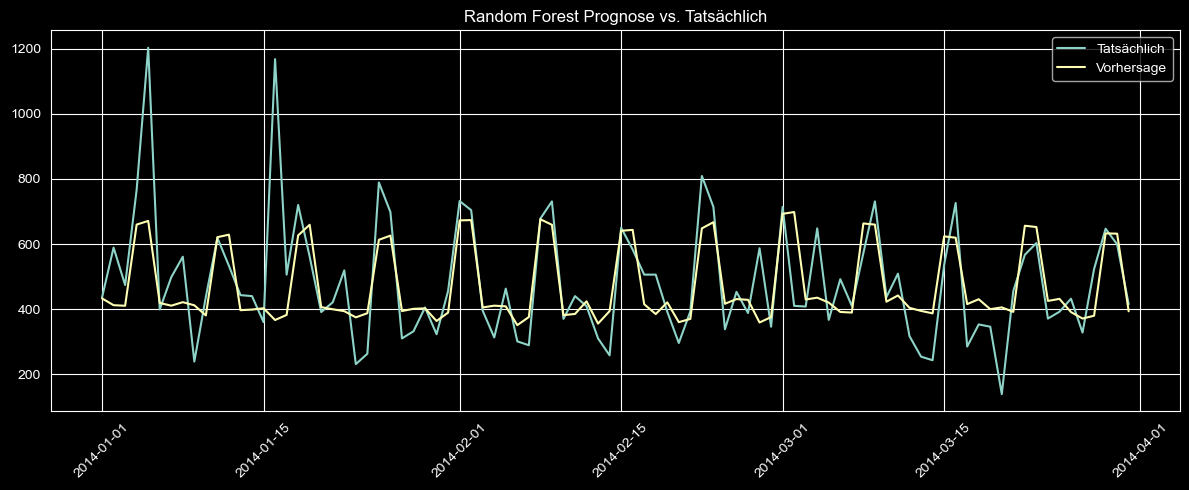

In [50]:
import matplotlib.pyplot as plt

test_dates_RF = time_series_ALL_features_NAsDropped[
    (time_series_ALL_features_NAsDropped['date'] >= '2014-01-01') &
    (time_series_ALL_features_NAsDropped['date'] <= '2014-03-31')
]['date'].values

fig_RF, ax = plt.subplots(figsize=(12, 5))
ax.plot(test_dates_RF, y_test.values, label='Tatsächlich')
ax.plot(test_dates_RF, y_pred_rf, label='Vorhersage')
ax.legend()
ax.set_title('Random Forest Prognose vs. Tatsächlich')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

### Feature Importance Plot

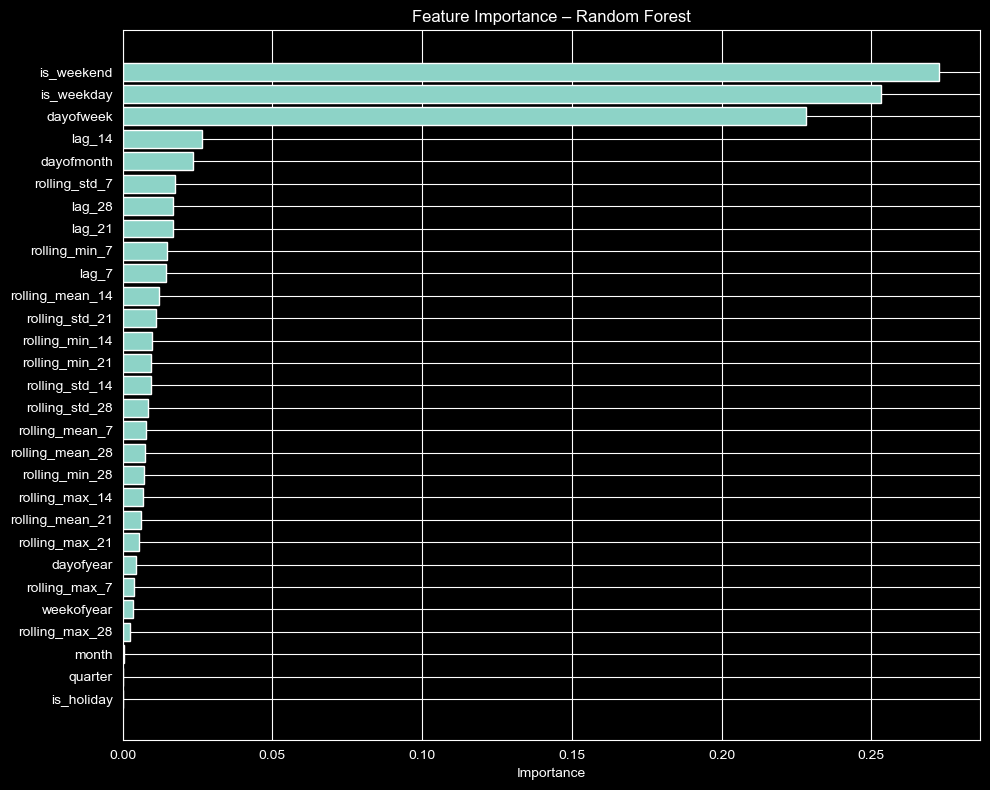

In [51]:
# Feature Importance Plot mit fig-Objekt erstellen (nötig für mlflow.log_figure)
importance_rf_final = pd.DataFrame({
    "Feature":    X_train.columns,
    "Importance": final_model_RF.feature_importances_
}).sort_values("Importance", ascending=True)

fig_RF_importance, ax = plt.subplots(figsize=(10, 8))
ax.barh(importance_rf_final["Feature"], importance_rf_final["Importance"])
ax.set_xlabel("Importance")
ax.set_title("Feature Importance – Random Forest")
plt.tight_layout()
plt.show()

## ML FLow

### Starten

In [1]:
import mlflow
import mlflow.xgboost

mlflow.set_tracking_uri("sqlite:////Users/matthiasmuschket/PycharmProjects/260414_Time_Series_Masterschool/mlflow.db")
mlflow.set_experiment("sales_forecast")

# Jetzt wichtig: mlflow ui mit der DB starten. Im Terminal:
# mlflow ui --backend-store-uri sqlite:////Users/matthiasmuschket/PycharmProjects/260414_Time_Series_Masterschool/mlflow.db

/opt/miniconda3/envs/work/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


<Experiment: artifact_location='/Users/matthiasmuschket/PycharmProjects/260414_Time_Series_Masterschool/Scripts/mlruns/1', creation_time=1777470068881, experiment_id='1', last_update_time=1777470068881, lifecycle_stage='active', name='sales_forecast', tags={}, trace_location=None, workspace='default'>

### Logging

In [53]:
with mlflow.start_run(run_name="Random_Forest"):

    # Qualitative Zusatzinfos
    mlflow.set_tag("forecasting_method", "one-step-ahead")
    mlflow.set_tag("model_type", "ML")

    # Beste Hyperparameter loggen
    mlflow.log_params(best_params_RF)

    # Train/Test-Split Info loggen
    mlflow.log_param("train_size", len(X_train))
    mlflow.log_param("test_size", len(X_test))
    mlflow.log_param("test_start", "2014-01-01")
    mlflow.log_param("test_end", "2014-03-31")

    # Genutzte Features loggen
    mlflow.log_param("features", list(X_train.columns))

    # Evaluationsmetriken loggen
    mlflow.log_metric("SMAPE", metrics_RF["SMAPE"])
    mlflow.log_metric("RMSE",  metrics_RF["RMSE"])
    mlflow.log_metric("MAD",   metrics_RF["MAD"])
    mlflow.log_metric("rMAD",  metrics_RF["rMAD"])
    mlflow.log_metric("MAPE",  metrics_RF["MAPE"])
    mlflow.log_metric("Bias",  metrics_RF["Bias"])

    # Forecast-Plot als Artefakt speichern
    mlflow.log_figure(fig_RF, "forecast_plot.png")

    # Feature Importance Plot als Artefakt speichern
    mlflow.log_figure(fig_RF_importance, "feature_importance.png")

    # Trainiertes Modell speichern (sklearn flavor)
    mlflow.sklearn.log_model(final_model_RF, name="model")

2026/04/30 13:59:59 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


### Load and use the logged model

In [34]:
# You need the run ID - get it from MLflow UI or by searching
run_id = "6e10116ffc4d4ca09bd73775f14307e5"

# Load the model
model_uri = f"runs:/{run_id}/model"  # or "/linear_regression_model" if you used custom name
loaded_model = mlflow.sklearn.load_model(model_uri)

print("Model loaded successfully!")
print(f"Model type: {type(loaded_model)}")

Model loaded successfully!
Model type: <class 'sklearn.ensemble._forest.RandomForestRegressor'>


## Iteratives Forecasting mit optimierten Hyperparametern

In [32]:
print(time_series_ALL_features_NAsDropped['date'].max())

2014-03-31 00:00:00


In [40]:
import pandas as pd
import numpy as np

# ── Iterativer Forecast mit Random Forest ─────────────────────────────

# (1) Ausgangsdaten – alle bekannten Daten als Basis
df_forecast = time_series_ALL_features_NAsDropped.copy()

# (2) Forecast-Horizont definieren
forecast_horizon = 90  # Anzahl Tage in die Zukunft

# (3) Iterativer Forecast
predictions = []

# Berechnung der Features, die in der Zukunft liegen => Liste "predictions" wird erzeugt
for i in range(forecast_horizon):

    # Letztes bekanntes Datum
    last_date = df_forecast['date'].max()
    next_date = last_date + pd.Timedelta(days=1)

    # Zeitbasierte Features für den nächsten Tag berechnen (immer bekannt)
    new_row = {
        'date':        next_date,
        'dayofweek':   next_date.dayofweek,
        'dayofmonth':  next_date.day,
        'dayofyear':   next_date.dayofyear,
        'weekofyear':  next_date.isocalendar().week,
        'month':       next_date.month,
        'quarter':     next_date.quarter,
        'is_weekend':  int(next_date.dayofweek >= 5),
        'is_weekday':  int(next_date.dayofweek < 5),
        'is_holiday':  0,  # vereinfacht: kein Feiertag
    }

    # Lag-Features aus bekannten + bereits vorhergesagten Werten berechnen
    all_sales = df_forecast['unit_sales'].values

    new_row['lag_7']  = all_sales[-7]
    new_row['lag_14'] = all_sales[-14]
    new_row['lag_21'] = all_sales[-21]
    new_row['lag_28'] = all_sales[-28]

    # Rolling Features
    new_row['rolling_mean_7']  = np.mean(all_sales[-7:])
    new_row['rolling_mean_14'] = np.mean(all_sales[-14:])
    new_row['rolling_mean_21'] = np.mean(all_sales[-21:])
    new_row['rolling_mean_28'] = np.mean(all_sales[-28:])

    new_row['rolling_std_7']   = np.std(all_sales[-7:])
    new_row['rolling_std_14']  = np.std(all_sales[-14:])
    new_row['rolling_std_21']  = np.std(all_sales[-21:])
    new_row['rolling_std_28']  = np.std(all_sales[-28:])

    new_row['rolling_max_7']   = np.max(all_sales[-7:])
    new_row['rolling_max_14']  = np.max(all_sales[-14:])
    new_row['rolling_max_21']  = np.max(all_sales[-21:])
    new_row['rolling_max_28']  = np.max(all_sales[-28:])

    new_row['rolling_min_7']   = np.min(all_sales[-7:])
    new_row['rolling_min_14']  = np.min(all_sales[-14:])
    new_row['rolling_min_21']  = np.min(all_sales[-21:])
    new_row['rolling_min_28']  = np.min(all_sales[-28:])

    # Feature-Vektor für Vorhersage erstellen
    feature_cols = []

    for col in df_forecast.columns:             # -> Gehe durch alle Spaltennamen in df_forecast
        if col not in ['date', 'unit_sales']:   # -> Wenn der Spaltenname nicht date oder unit_sales ist
            feature_cols.append(col)            # -> Füge ihn zur Liste feature_cols hinzu

    X_new = pd.DataFrame([new_row])[feature_cols]

    # Vorhersage
    y_pred = loaded_model.predict(X_new)[0]
    predictions.append({'date': next_date, 'unit_sales_forecast': y_pred})

    # Vorhergesagten Wert zu df_forecast hinzufügen für nächste Iteration
    new_row['unit_sales'] = y_pred
    df_forecast = pd.concat([df_forecast, pd.DataFrame([new_row])], ignore_index=True)

In [38]:
df_predictions

,date,unit_sales_forecast
0,2014-04-01,418.285930
1,2014-04-02,408.085288
2,2014-04-03,375.808643
3,2014-04-04,418.671692
4,2014-04-05,658.000235
...,...,...
85,2014-06-25,426.131931
86,2014-06-26,402.092701
87,2014-06-27,407.868706
88,2014-06-28,620.697734


In [39]:
df_forecast

,date,unit_sales,is_weekday,is_holiday,dayofweek,dayofmonth,dayofyear,weekofyear,month,quarter,...,rolling_std_21,rolling_std_28,rolling_max_7,rolling_max_14,rolling_max_21,rolling_max_28,rolling_min_7,rolling_min_14,rolling_min_21,rolling_min_28
0,2013-01-30,487.000000,1,0,2,30,30,5,1,1,...,250.878722,241.421167,697.000000,1090.000000,1090.000000,1090.000000,318.000000,4.000000,4.000000,4.000000
1,2013-01-31,282.000000,1,0,3,31,31,5,1,1,...,250.501193,241.339173,697.000000,1090.000000,1090.000000,1090.000000,318.000000,4.000000,4.000000,4.000000
2,2013-02-01,401.000000,1,0,4,1,32,5,2,1,...,252.053792,242.328374,697.000000,1090.000000,1090.000000,1090.000000,282.000000,60.000000,4.000000,4.000000
3,2013-02-02,775.000000,0,0,5,2,33,5,2,1,...,247.399657,240.804120,697.000000,1090.000000,1090.000000,1090.000000,282.000000,282.000000,4.000000,4.000000
4,2013-02-03,855.000000,0,0,6,3,34,5,2,1,...,253.589019,244.202804,775.000000,1090.000000,1090.000000,1090.000000,282.000000,282.000000,4.000000,4.000000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
511,2014-06-25,426.131931,1,0,2,25,176,26,6,2,...,101.203950,101.620863,633.252026,634.136343,663.486442,668.821922,399.199996,398.099442,398.099442,398.099442
512,2014-06-26,402.092701,1,0,3,26,177,26,6,2,...,101.297424,101.675259,633.252026,634.136343,663.486442,668.821922,399.199996,398.099442,398.099442,398.099442
513,2014-06-27,407.868706,1,0,4,27,178,26,6,2,...,101.352274,101.719717,633.252026,634.136343,663.486442,668.821922,402.092701,399.199996,398.099442,398.099442
514,2014-06-28,620.697734,0,0,5,28,179,26,6,2,...,101.365934,101.754193,633.252026,634.136343,663.486442,668.821922,402.092701,399.199996,398.099442,398.099442


         date  unit_sales_forecast
0  2014-04-01           418.285930
1  2014-04-02           408.085288
2  2014-04-03           375.808643
3  2014-04-04           418.671692
4  2014-04-05           658.000235
..        ...                  ...
85 2014-06-25           426.131931
86 2014-06-26           402.092701
87 2014-06-27           407.868706
88 2014-06-28           620.697734
89 2014-06-29           638.474891

[90 rows x 2 columns]


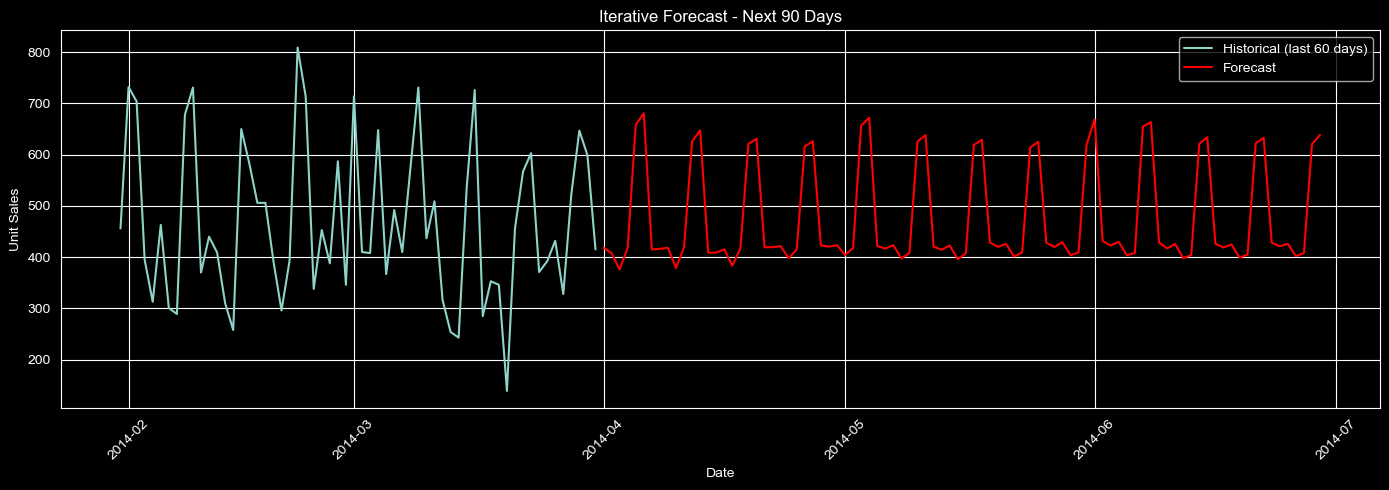

In [41]:
# (4) Ergebnisse als DataFrame
df_predictions = pd.DataFrame(predictions)
print(df_predictions)

# (5) Plot
fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(time_series_ALL_features_NAsDropped['date'].tail(60),
        time_series_ALL_features_NAsDropped['unit_sales'].tail(60),
        label='Historical (last 60 days)')
ax.plot(df_predictions['date'], df_predictions['unit_sales_forecast'],
        label='Forecast', color='red')
ax.set_xlabel("Date")
ax.set_ylabel("Unit Sales")
ax.set_title(f"Iterative Forecast - Next {forecast_horizon} Days")
ax.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()